In [4]:
import pandas as pd
from sklearn.cluster import KMeans

# 1. Acessar o CSV
df = pd.read_csv('customer_support_tickets.csv')

# 2. Converter datas e calcular o tempo de resolução (em horas)
df['First Response Time'] = pd.to_datetime(df['First Response Time'], errors='coerce')
df['Time to Resolution'] = pd.to_datetime(df['Time to Resolution'], errors='coerce')
df['Tempo_Resolucao_Horas'] = (df['Time to Resolution'] - df['First Response Time']).dt.total_seconds() / 3600

# 3. Descobrir SLA Ideal: Resolvido ('Closed') e Satisfação > Média
media_satisfacao = df['Customer Satisfaction Rating'].mean()
df_ideal = df[(df['Ticket Status'] == 'Closed') & (df['Customer Satisfaction Rating'] > media_satisfacao)].copy()
df_ideal = df_ideal.dropna(subset=['Tempo_Resolucao_Horas', 'Customer Satisfaction Rating'])

# 4. Criar clusters com os tickets do cenário ideal
X = df_ideal[['Tempo_Resolucao_Horas', 'Customer Satisfaction Rating']]
kmeans = KMeans(n_clusters=3, random_state=42) # 3 perfis de SLA
df_ideal['Cluster'] = kmeans.fit_predict(X)

# 5. Visualizar o SLA bom com base nos clusters
print(f"Satisfação Média: {media_satisfacao:.2f}")
print("Média de Tempo de Resolução e Satisfação por Cluster (Seu SLA alvo):")
print(df_ideal.groupby('Cluster')[['Tempo_Resolucao_Horas', 'Customer Satisfaction Rating']].mean())

Satisfação Média: 2.99
Média de Tempo de Resolução e Satisfação por Cluster (Seu SLA alvo):
         Tempo_Resolucao_Horas  Customer Satisfaction Rating
Cluster                                                     
0                    11.775852                      3.995556
1                     0.504918                      3.979508
2                   -11.277113                      3.960825


In [5]:
import pandas as pd

# 1. Carregar dados e preparar datas
df = pd.read_csv('customer_support_tickets.csv')
df['First Response Time'] = pd.to_datetime(df['First Response Time'], errors='coerce')
df['Time to Resolution'] = pd.to_datetime(df['Time to Resolution'], errors='coerce')

# Calcular tempo em horas e remover erros (tempos negativos)
df['Tempo_Resolucao_Horas'] = (df['Time to Resolution'] - df['First Response Time']).dt.total_seconds() / 3600
df = df[df['Tempo_Resolucao_Horas'] > 0].copy()

sla_horas = 11

# 2. Encontrar Piores Gargalos (Acima do SLA)
df_atrasados = df[df['Tempo_Resolucao_Horas'] > sla_horas].copy()
gargalos = df_atrasados.groupby(['Ticket Channel', 'Ticket Priority', 'Ticket Type'])['Tempo_Resolucao_Horas'].mean().reset_index()
piores_gargalos = gargalos.sort_values(by='Tempo_Resolucao_Horas', ascending=False).head(3)

# 3. Calcular Correlações
cols_cat = ['Ticket Channel', 'Ticket Priority', 'Ticket Type']
df_corr = df.copy()
for col in cols_cat: # Converte texto em números para a correlação
    df_corr[col] = df_corr[col].astype('category').cat.codes

corr = df_corr.corr(numeric_only=True)['Customer Satisfaction Rating'].sort_values(key=abs, ascending=False)

# 4. Calcular Custo Perdido
df_atrasados['Horas_Atraso'] = df_atrasados['Tempo_Resolucao_Horas'] - sla_horas
custo_perdido = df_atrasados['Horas_Atraso'].sum() * 15 # R$ 15/h

print("--- Piores Gargalos ---")
print(piores_gargalos)
print("\n--- Correlações ---")
print(corr)
print(f"\n--- Custo Total Perdido: R$ {custo_perdido:.2f} ---")

--- Piores Gargalos ---
   Ticket Channel Ticket Priority      Ticket Type  Tempo_Resolucao_Horas
77   Social media          Medium  Product inquiry              19.975000
35          Email          Medium  Billing inquiry              19.711111
34          Email             Low  Technical issue              18.987500

--- Correlações ---
Customer Satisfaction Rating    1.000000
Ticket Type                    -0.072974
Ticket Channel                 -0.039608
Ticket ID                      -0.031403
Ticket Priority                 0.013945
Tempo_Resolucao_Horas          -0.004971
Customer Age                    0.001243
Name: Customer Satisfaction Rating, dtype: float64

--- Custo Total Perdido: R$ 24660.25 ---


In [6]:
import pandas as pd

# 1. Carregar os dados e converter datas
df = pd.read_csv('customer_support_tickets.csv')
df['First Response Time'] = pd.to_datetime(df['First Response Time'], errors='coerce')
df['Time to Resolution'] = pd.to_datetime(df['Time to Resolution'], errors='coerce')

# 2. Calcular tempo de resolução em horas e remover erros/negativos
df['Tempo_Resolucao_Horas'] = (df['Time to Resolution'] - df['First Response Time']).dt.total_seconds() / 3600
df = df[df['Tempo_Resolucao_Horas'] > 0].copy()

# 3. Agrupar por Tipo de Ticket e analisar médias e medianas
analise_tipo = df.groupby('Ticket Type')['Tempo_Resolucao_Horas'].agg(
    Média_Horas='mean',
    Mediana_Horas='median',
    Volume_Tickets='count'
).reset_index()

# Ordenar do mais demorado para o mais rápido
analise_tipo = analise_tipo.sort_values(by='Média_Horas', ascending=False)

print(analise_tipo.to_string(index=False))

         Ticket Type  Média_Horas  Mediana_Horas  Volume_Tickets
      Refund request     8.144609       6.716667             303
     Product inquiry     7.706055       6.991667             256
Cancellation request     7.693082       6.366667             265
     Technical issue     7.365191       6.383333             305
     Billing inquiry     7.010256       5.266667             273


In [7]:
import pandas as pd

df = pd.read_csv('customer_support_tickets.csv')

# Agrupar por Tipo de Ticket e calcular a média das notas
notas_tipo = df.groupby('Ticket Type')['Customer Satisfaction Rating'].agg(
    Nota_Média='mean',
    Volume='count'
).reset_index()

# Ordenar da melhor nota para a pior
notas_tipo = notas_tipo.sort_values(by='Nota_Média', ascending=False)

print(notas_tipo.to_string(index=False))

         Ticket Type  Nota_Média  Volume
Cancellation request    3.029070     516
     Billing inquiry    3.027574     544
     Product inquiry    3.016886     533
     Technical issue    2.958621     580
      Refund request    2.934564     596


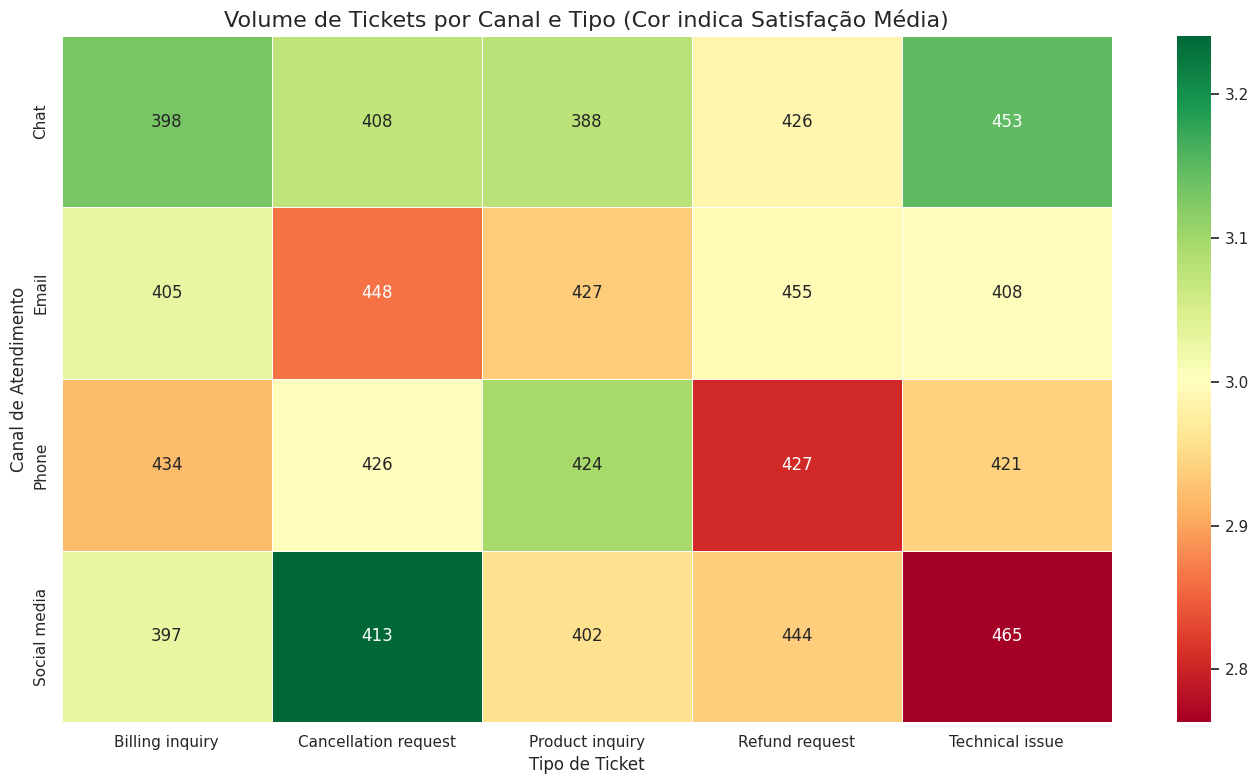

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Carregar os dados
df = pd.read_csv('customer_support_tickets.csv')

# 1. Tabela para as CORES (Média da Nota)
pivot_notas = df.pivot_table(
    index='Ticket Channel',
    columns='Ticket Type',
    values='Customer Satisfaction Rating',
    aggfunc='mean'
)

# 2. Tabela para os NÚMEROS no quadrado (Quantidade de Tickets atendidos)
pivot_volume = df.pivot_table(
    index='Ticket Channel',
    columns='Ticket Type',
    values='Ticket ID',
    aggfunc='count'
)

# 3. Gerar o gráfico
fig, ax = plt.subplots(figsize=(14, 8))

# data=pivot_notas define as cores
# annot=pivot_volume coloca o número total de tickets dentro do quadrado
sns.heatmap(
    data=pivot_notas,
    annot=pivot_volume,
    fmt=".0f", # Mostra o número redondo (sem casas decimais)
    cmap='RdYlGn',
    linewidths=.5,
    ax=ax
)

ax.set_title('Volume de Tickets por Canal e Tipo (Cor indica Satisfação Média)', fontsize=16)
ax.set_xlabel('Tipo de Ticket', fontsize=12)
ax.set_ylabel('Canal de Atendimento', fontsize=12)

plt.tight_layout()
plt.savefig('heatmap_volume_notas.png')